In [71]:
import numpy as np 
import fitsio

import os
import sys
import matplotlib.pyplot as plt

In [72]:
sys.path.append('../plotting_script/')
from Plot_twopt import *

In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

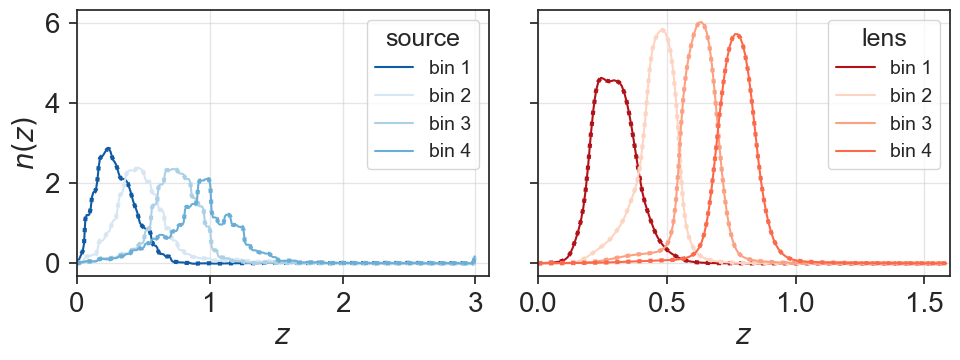

In [75]:
titles = ['source', 'lens']
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for k in range(2):
    for i in range(4):
        z = np.genfromtxt('../output/des-y3/nz_'+titles[k]+'/z.txt')
        n_of_z = np.genfromtxt('../output/des-y3/nz_'+titles[k]+'/bin_'+str(i+1)+'.txt')
        ax[k].plot(z, n_of_z, label='bin ' + str(i + 1), color=sns.color_palette("Blues", 5)[i-1] if k==0 else sns.color_palette("Reds", 5)[i-1], linewidth=1.5)

        z = np.genfromtxt('../output/des-y3-testing/nz_'+titles[k]+'/z.txt')
        n_of_z = np.genfromtxt('../output/des-y3-testing/nz_'+titles[k]+'/bin_'+str(i+1)+'.txt')
        ax[k].plot(z, n_of_z,color=sns.color_palette("Blues", 5)[i-1] if k==0 else sns.color_palette("Reds", 5)[i-1], linestyle=':', linewidth=3)
    ax[k].set_xlabel("$z$")
    ax[k].legend(loc='upper right', title=titles[k], title_fontsize=18)
    ax[k].grid(alpha=0.5)
ax[0].set_ylabel("$n(z)$")
ax[0].set_xlim(0, 3.1)
ax[1].set_xlim(0, 1.6)
plt.tight_layout()

In [76]:
pk_nl_cosmosis = np.genfromtxt('../output/des-y3/matter_power_nl/p_k.txt')
k_cosmosis = np.genfromtxt('../output/des-y3/matter_power_nl/k_h.txt')
z_cosmosis = np.genfromtxt('../output/des-y3/matter_power_nl/z.txt')
pk_nl_ccl = np.genfromtxt('../output/des-y3-testing/matter_power_nl/p_k.txt')
k_ccl = np.genfromtxt('../output/des-y3-testing/matter_power_nl/k_h.txt')
z_ccl = np.genfromtxt('../output/des-y3-testing/matter_power_nl/z.txt')

/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_10798/3682353111.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0][i].legend(title=f'$z={z_ccl[z_indices[i]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)


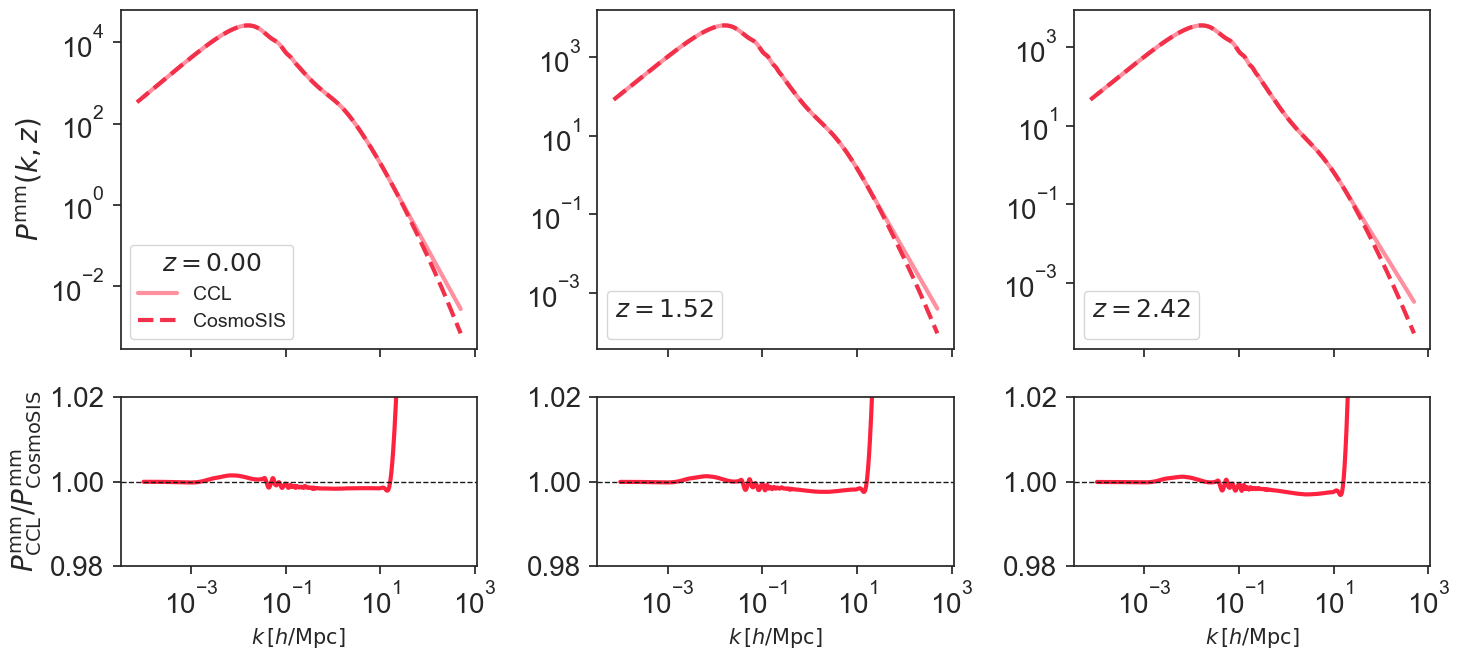

In [78]:
from scipy import interpolate

z_indices = [0, 75, 120]
fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for i in range(len(z_indices)):
    ax[0][i].loglog(k_ccl, pk_nl_ccl[z_indices[i]], color="#FF909F", label='CCL' if i == 0 else '')
    ax[0][i].loglog(k_cosmosis, pk_nl_cosmosis[z_indices[i]], color="#F3304A", linestyle='--', label='CosmoSIS' if i == 0 else '')
    ax[0][i].legend(title=f'$z={z_ccl[z_indices[i]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)
    interp_cosmosis = interpolate.interp1d(k_cosmosis, pk_nl_cosmosis[z_indices[i]], kind='cubic')
    ax[1][i].plot(k_ccl, pk_nl_ccl[z_indices[i]]/interp_cosmosis(k_ccl), color='#FF223F')
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][i].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][i].set_ylim(0.98, 1.02)


ax[0][0].set_ylabel("$P^{\\rm mm}(k, z)$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm CCL}/P_{\\rm CosmoSIS}^{\\rm mm}$")
plt.tight_layout()

/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_10798/2936840072.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[i, j].semilogx(ell, cosmosis/ccl, linewidth=2)
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_10798/2936840072.py:15: RuntimeWarning: divide by zero encountered in divide
  ax[i, j].semilogx(ell, cosmosis/ccl, linewidth=2)


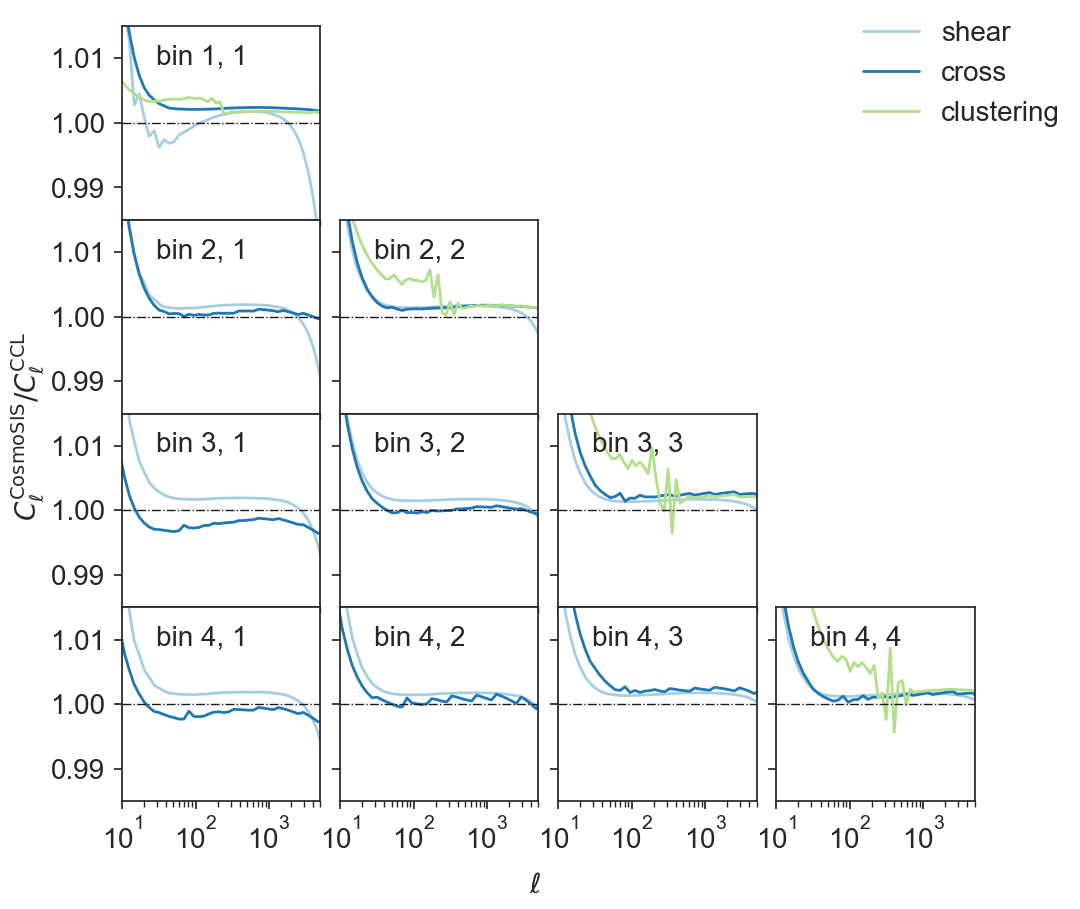

In [177]:
nbin = 4 # number of tomographic bins for shear/position
ell = np.genfromtxt('../output/des-y3/shear_cl/ell.txt')
labels = ['shear', 'cross', 
'clustering']
fig, ax = plt.subplots(nbin, nbin, figsize=(11, 10), sharey=True, sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            cosmosis = np.genfromtxt('../output/des-y3/shear_cl/bin_'+str(i+1)+'_'+str(j+1)+'.txt')
            ccl = np.genfromtxt('../output/des-y3-ccl/shear_cl/bin_'+str(i+1)+'_'+str(j+1)+'.txt')
            ax[i, j].semilogx(ell, cosmosis/ccl, linewidth=2)

            cosmosis = np.genfromtxt('../output/des-y3/galaxy_shear_cl/bin_'+str(i+1)+'_'+str(j+1)+'.txt')
            ccl = np.genfromtxt('../output/des-y3-ccl/galaxy_shear_cl/bin_'+str(i+1)+'_'+str(j+1)+'.txt')
            ax[i, j].semilogx(ell, cosmosis/ccl, linewidth=2)

            if i == j:
                ell_gg = np.genfromtxt('../output/des-y3/galaxy_cl/ell.txt')
                cosmosis = np.genfromtxt('../output/des-y3/galaxy_cl/bin_'+str(i+1)+'_'+str(j+1)+'.txt')
                ccl = np.genfromtxt('../output/des-y3-ccl/galaxy_cl/bin_'+str(i+1)+'_'+str(j+1)+'.txt')
                ell_gg_ccl = np.genfromtxt('../output/des-y3-ccl/galaxy_cl/ell.txt')
                interp_ccl = interpolate.interp1d(ell_gg_ccl, ccl, kind='cubic')
                ax[i, j].semilogx(ell_gg, cosmosis/interp_ccl(ell_gg), linewidth=2)
            ax[i, j].set_ylim(0.985, 1.015)#(0.985, 1.015)
            ax[i, j].set_xlim(10, 5000)
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) if i==4 else ax[i,j].text(.4, .8, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=1, color='k')
        else:
            ax[i,j].axis('off')      

fig.text(0.04, 0.5, r'$C^{\rm CosmoSIS}_\ell/C^{\rm CCL}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

In [171]:
path_dv='/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library/'
path_save = os.path.join(path_dv,'plotting_script/data_vectors')

In [172]:
fname_dv_list=[ # dark scattering sim dv 
                #os.path.join(path_dv,'likelihood/des-y3/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'),   
                os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test.fits'),
                #os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test_noPM.fits'),
                os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test.fits'),
                os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test_ccl.fits'),
                #os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test_RSD_noLimber_nomagn.fits'),
                #os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test_RSD_noLimber_nomagn.fits'),
                #os.path.join(path_dv, 'likelihood/des-y3/sim_d-gen2pt_simy3_l-hm20-nla-magy3balfix_ml4_sy3_test_RSD_noLimber_nomagn_ccl.fits'),

                ]

scalecuts_list = [
                  path_dv+'examples/y3-scales-ml4_3x2pt_8_6_0.5_v0.40.ini'
                  ]

label_list=[#'real data', 
'CosmoSIS', 'CosmoSIS: no PM', 
'CCL']

#################################
###        COSMIC SHEAR       ###
#################################


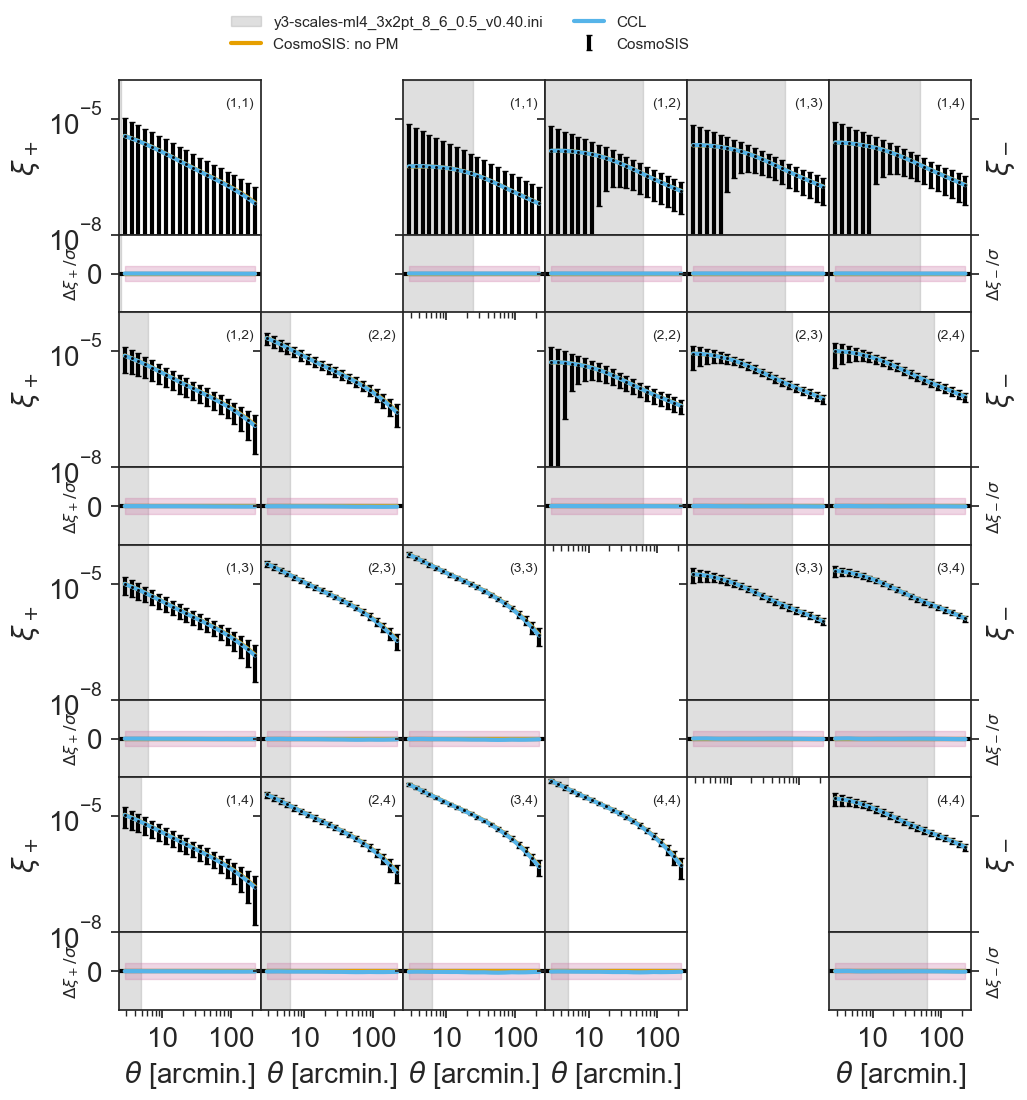

In [173]:
plot_cshear_w_dif(fname_dv_list=fname_dv_list,
            label_list=label_list,
            scalecuts_list=scalecuts_list,
            path_save=path_save,
            flag_line=[False, True, True, True])

#################################
###        GGLENSING          ###
#################################


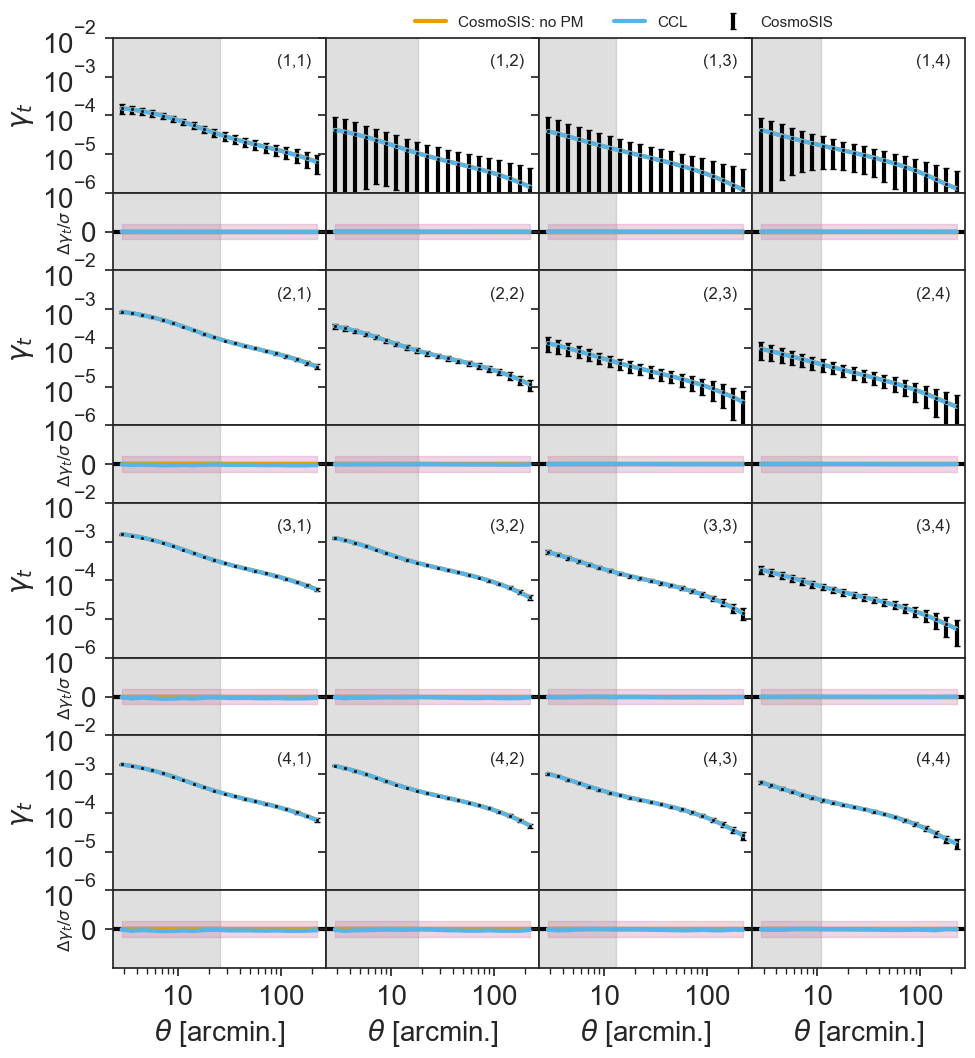

In [174]:
plot_gammat_w_dif(fname_dv_list=fname_dv_list,
            label_list=label_list,
            scalecuts_list=scalecuts_list,
            #prefactor=True,
            path_save=path_save,
            #need_pdf=False,
            flag_line=[False, True, True, True], num_unused=2
            )

#################################
###        WTHETA             ###
#################################


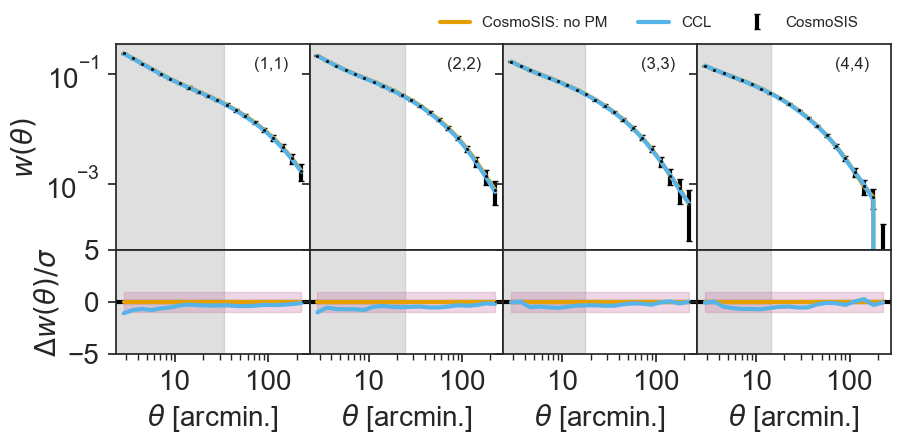

In [175]:
plot_wtheta_w_dif(fname_dv_list=fname_dv_list,
            label_list=label_list,
            scalecuts_list=scalecuts_list,
            #|prefactor=True,
            path_save=path_save,
            #need_pdf=False,
            flag_line=[False, True, True, True], num_unused=2
            )

In [ ]:
plot_cshear(fname_dv_list=fname_dv_list,
            label_list=label_list,
            scalecuts_list=scalecuts_list,
            prefactor=True,
            path_save=path_save,
            #need_pdf=True,
            flag_line=[False, True, True])
plot_gammat(fname_dv_list=fname_dv_list,
            label_list=label_list,
            scalecuts_list=scalecuts_list,
            #prefactor=True,
            path_save=path_save,
            #need_pdf=False,
            flag_line=[False, True, True]
            )   
plot_wtheta(fname_dv_list=fname_dv_list,
            label_list=label_list,
            scalecuts_list=scalecuts_list,
            #|prefactor=True,
            path_save=path_save,
            #need_pdf=False,
            flag_line=[False, True, True]
            )         